# Klasifikasi Penyakit Jantung dengan Logistic Regression

**Seri Praktik Data Science — Menata Data Lab · B2**

Notebook ini adalah panduan lengkap dari **pengumpulan data** hingga **deployment model**, mengikuti alur ebook *Klasifikasi Penyakit Jantung dengan Logistic Regression*.

---

| Komponen | Detail |
|----------|--------|
| **Model ML** | Logistic Regression (Binary Classification) |
| **Bidang** | Kesehatan — Deteksi Dini Penyakit Jantung |
| **Dataset** | Heart Disease UCI · 303 pasien · 14 variabel |
| **Tools** | Python 3.12 · pandas · NumPy · scikit-learn · matplotlib · seaborn |

---

### Alur Pembahasan

1. **Bab 1** — Pengumpulan & Loading Data
2. **Bab 2** — Teori Logistic Regression (Visualisasi Sigmoid)
3. **Bab 3** — Exploratory Data Analysis (EDA)
4. **Bab 4** — Preprocessing Data
5. **Bab 5** — Membangun Model Logistic Regression
6. **Bab 6** — Evaluasi Model
7. **Bab 7** — Visualisasi & Insight
8. **Bab 8** — Deployment: Prediksi Pasien Baru

> ⚠️ **Catatan**: Model ini dilatih pada dataset penelitian berskala kecil (303 pasien) dan **tidak boleh** digunakan untuk pengambilan keputusan klinis nyata tanpa validasi lebih lanjut oleh tenaga medis profesional.

---
## Bab 1 — Pengumpulan & Loading Data

Dataset berasal dari **Heart Disease Dataset** di UCI Machine Learning Repository, dikumpulkan dari pasien Cleveland Clinic Foundation (Detrano et al., 1989). Subset yang kita gunakan terdiri dari **303 baris** data pasien dengan **14 variabel klinis** (13 fitur + 1 target).

In [1]:
# Install library yang dibutuhkan (jalankan jika di Google Colab)
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
)
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

print('Semua library berhasil diimpor ✓')

Semua library berhasil diimpor ✓


In [3]:
# Muat dataset Heart Disease UCI dari sumber publik
url = 'https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv'

try:
    df = pd.read_csv(url)
    print(f'Dataset berhasil dimuat dari GitHub ({len(df)} baris)')
except Exception:
    # Fallback: muat file lokal (heart.csv harus ada di direktori yang sama)
    df = pd.read_csv('heart.csv')
    print(f'Dataset berhasil dimuat dari file lokal ({len(df)} baris)')

print(f'Kolom: {list(df.columns)}')
print(f'Dimensi: {df.shape}')

Dataset berhasil dimuat dari GitHub (303 baris)
Kolom: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Dimensi: (303, 14)


In [4]:
# Lihat 5 baris pertama
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# Informasi tipe data dan ukuran dataset
print(f'Dimensi dataset: {df.shape[0]} baris × {df.shape[1]} kolom')
print(f'\nTipe data per kolom:')
print(df.dtypes)
print(f'\nMemori: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')

Dimensi dataset: 303 baris × 14 kolom

Tipe data per kolom:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Memori: 33.3 KB


### Kamus Data — 14 Variabel Klinis

| Variabel | Deskripsi | Rentang / Kode |
|----------|-----------|----------------|
| `age` | Usia pasien (tahun) | 29 – 77 |
| `sex` | Jenis kelamin | 1=Pria, 0=Wanita |
| `cp` | Tipe nyeri dada (chest pain) | 0–3 |
| `trestbps` | Tekanan darah istirahat (mm Hg) | 94 – 200 |
| `chol` | Kolesterol serum (mg/dl) | 126 – 564 |
| `fbs` | Gula darah puasa >120 mg/dl | 1=Ya, 0=Tidak |
| `restecg` | Hasil EKG istirahat | 0–2 |
| `thalach` | Denyut jantung maksimum tercapai | 71 – 202 |
| `exang` | Angina akibat olahraga | 1=Ya, 0=Tidak |
| `oldpeak` | ST depression akibat olahraga | 0 – 6.2 |
| `slope` | Kemiringan segmen ST saat puncak | 0–2 |
| `ca` | Jumlah pembuluh darah pada fluoroscopy | 0–4 |
| `thal` | Hasil thalium stress test | 0–3 |
| `target` | **Label: keberadaan penyakit jantung** | **1=Ada, 0=Tidak** |

---
## Bab 2 — Teori Logistic Regression

Logistic Regression menggunakan **sigmoid function** untuk mengubah kombinasi linear fitur menjadi probabilitas (0–1):

$$p(z) = \frac{1}{1 + e^{-z}}$$

dengan $z = b_0 + b_1x_1 + b_2x_2 + ... + b_nx_n$

**Tiga konsep inti:**
- **Sigmoid** — mengubah skor linear menjadi probabilitas
- **Log-odds (logit)** — representasi linear: $\text{logit}(p) = \ln\left(\frac{p}{1-p}\right)$
- **Odds Ratio** — $e^{\text{koefisien}}$, cara membaca pengaruh tiap fitur

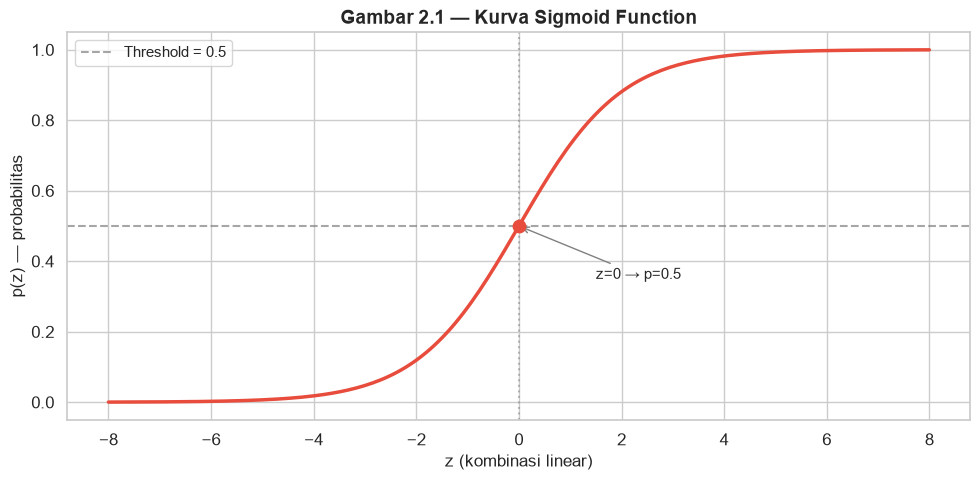

In [6]:
# Visualisasi Sigmoid Function
z = np.linspace(-8, 8, 200)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(z, sigmoid, color='#E74C3C', linewidth=2.5)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Threshold = 0.5')
ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)

# Anotasi titik penting
ax.scatter([0], [0.5], color='#E74C3C', s=80, zorder=5)
ax.annotate('z=0 → p=0.5', xy=(0, 0.5), xytext=(1.5, 0.35),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('z (kombinasi linear)', fontsize=12)
ax.set_ylabel('p(z) — probabilitas', fontsize=12)
ax.set_title('Gambar 2.1 — Kurva Sigmoid Function', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

---
## Bab 3 — Exploratory Data Analysis (EDA)

Sebelum membangun model, kita perlu memahami data secara menyeluruh.

### 3.1 Statistik Deskriptif

In [7]:
# Statistik deskriptif seluruh variabel
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [8]:
# Cek missing value
missing = df.isnull().sum()
print(f'Total missing value: {missing.sum()}')
print(f'\nMissing per kolom:')
print(missing)

Total missing value: 0

Missing per kolom:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### 3.2 Distribusi Kelas Target

Langkah wajib sebelum pemodelan: periksa keseimbangan kelas.

Distribusi Kelas Target:
  1 (Ada Penyakit)    : 165 pasien (54.5%)
  0 (Tidak Ada)       : 138 pasien (45.5%)


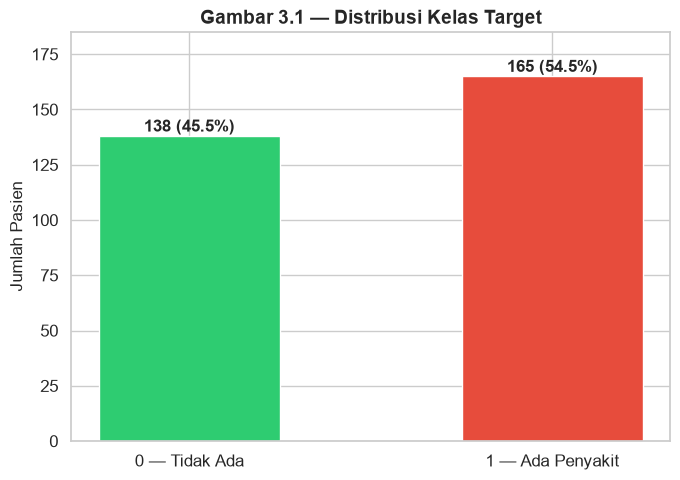

In [9]:
# Distribusi target
target_counts = df['target'].value_counts()
target_pct = df['target'].value_counts(normalize=True) * 100

print('Distribusi Kelas Target:')
print(f'  1 (Ada Penyakit)    : {target_counts[1]} pasien ({target_pct[1]:.1f}%)')
print(f'  0 (Tidak Ada)       : {target_counts[0]} pasien ({target_pct[0]:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2ECC71', '#E74C3C']
bars = ax.bar(['0 — Tidak Ada', '1 — Ada Penyakit'], target_counts.sort_index(), color=colors, edgecolor='white', width=0.5)

for bar, count, pct in zip(bars, target_counts.sort_index(), target_pct.sort_index()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{count} ({pct:.1f}%)', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Jumlah Pasien', fontsize=12)
ax.set_title('Gambar 3.1 — Distribusi Kelas Target', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(target_counts) + 20)
plt.tight_layout()
plt.show()

### 3.3 Eksplorasi Fitur Kategorikal

Distribusi jenis kelamin dan tipe nyeri dada (`cp`) terhadap target.

In [10]:
# Distribusi jenis kelamin
sex_counts = df['sex'].value_counts()
print(f'Pria (1) : {sex_counts[1]} ({sex_counts[1]/len(df)*100:.0f}%)')
print(f'Wanita (0): {sex_counts[0]} ({sex_counts[0]/len(df)*100:.0f}%)')

Pria (1) : 207 (68%)
Wanita (0): 96 (32%)


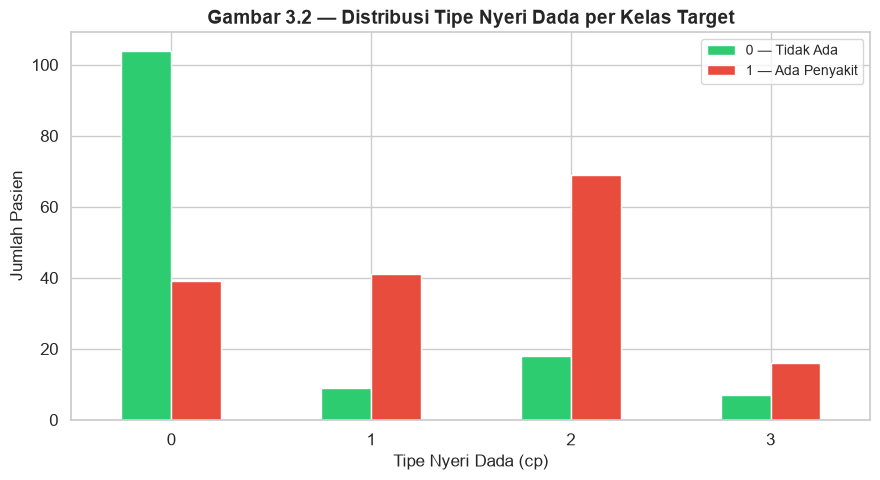

In [11]:
# Distribusi tipe nyeri dada (cp) berdasarkan target
fig, ax = plt.subplots(figsize=(9, 5))
ct = pd.crosstab(df['cp'], df['target'])
ct.plot(kind='bar', ax=ax, color=['#2ECC71', '#E74C3C'], edgecolor='white')

ax.set_xlabel('Tipe Nyeri Dada (cp)', fontsize=12)
ax.set_ylabel('Jumlah Pasien', fontsize=12)
ax.set_title('Gambar 3.2 — Distribusi Tipe Nyeri Dada per Kelas Target', fontsize=14, fontweight='bold')
ax.legend(['0 — Tidak Ada', '1 — Ada Penyakit'], fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 3.4 Korelasi Fitur dengan Target

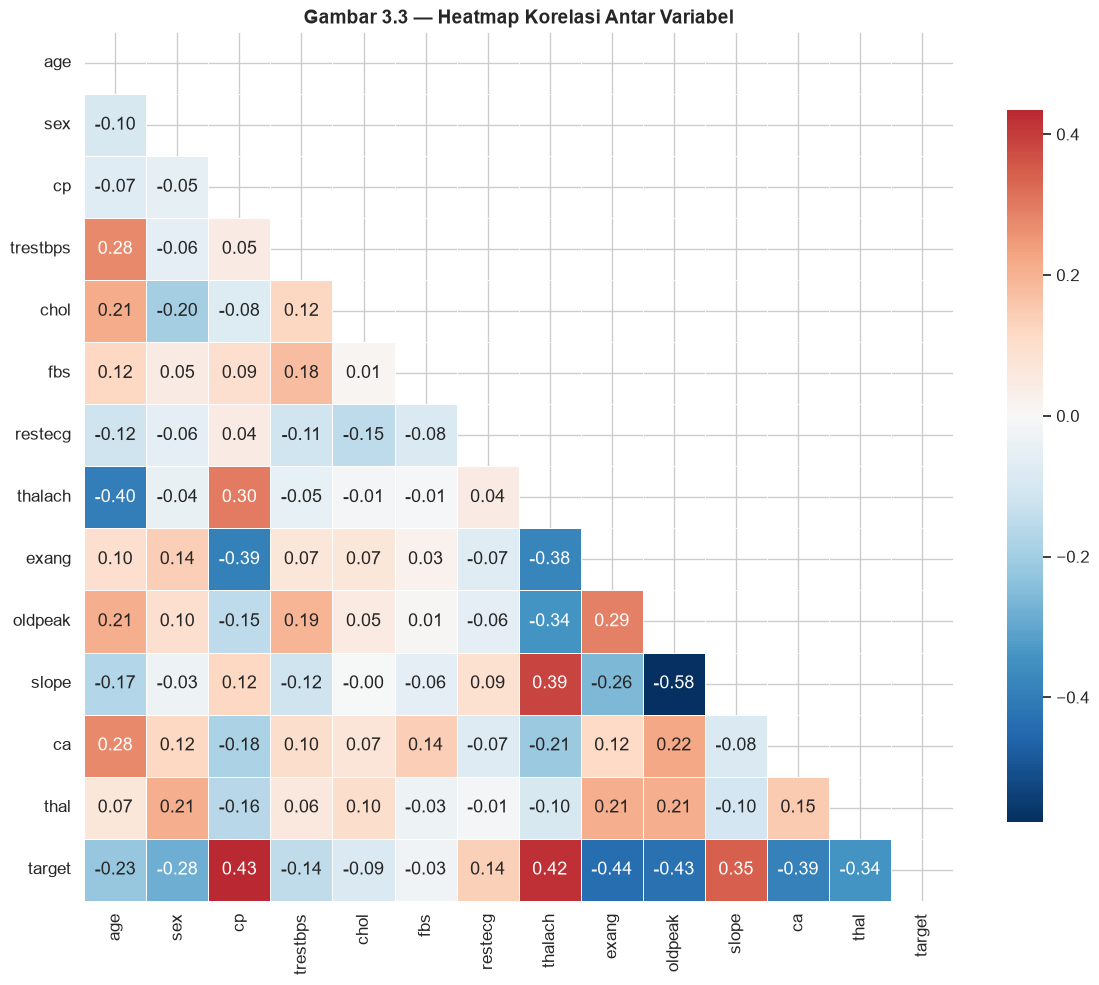

In [12]:
# Heatmap korelasi
fig, ax = plt.subplots(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Gambar 3.3 — Heatmap Korelasi Antar Variabel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Korelasi setiap fitur terhadap target, diurutkan
corr_target = df.corr()['target'].drop('target').sort_values(ascending=False)
print('Korelasi Pearson terhadap target (diurutkan):')
print('=' * 40)
for feat, val in corr_target.items():
    direction = '↑' if val > 0 else '↓'
    print(f'  {feat:12s} : {val:+.3f} {direction}')

Korelasi Pearson terhadap target (diurutkan):
  cp           : +0.434 ↑
  thalach      : +0.422 ↑
  slope        : +0.346 ↑
  restecg      : +0.137 ↑
  fbs          : -0.028 ↓
  chol         : -0.085 ↓
  trestbps     : -0.145 ↓
  age          : -0.225 ↓
  sex          : -0.281 ↓
  thal         : -0.344 ↓
  ca           : -0.392 ↓
  oldpeak      : -0.431 ↓
  exang        : -0.437 ↓


### 3.5 Distribusi Fitur Klinis per Kelas

In [14]:
# Perbandingan rata-rata fitur numerik per kelas
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
mean_by_target = df.groupby('target')[num_features].mean().round(1)
mean_by_target.index = ['Target=0 (Tidak Ada)', 'Target=1 (Ada Penyakit)']
print('Rata-rata Fitur Numerik per Kelas Target:')
mean_by_target

Rata-rata Fitur Numerik per Kelas Target:


,age,trestbps,chol,thalach,oldpeak
Target=0 (Tidak Ada),56.6,134.4,251.1,139.1,1.6
Target=1 (Ada Penyakit),52.5,129.3,242.2,158.5,0.6


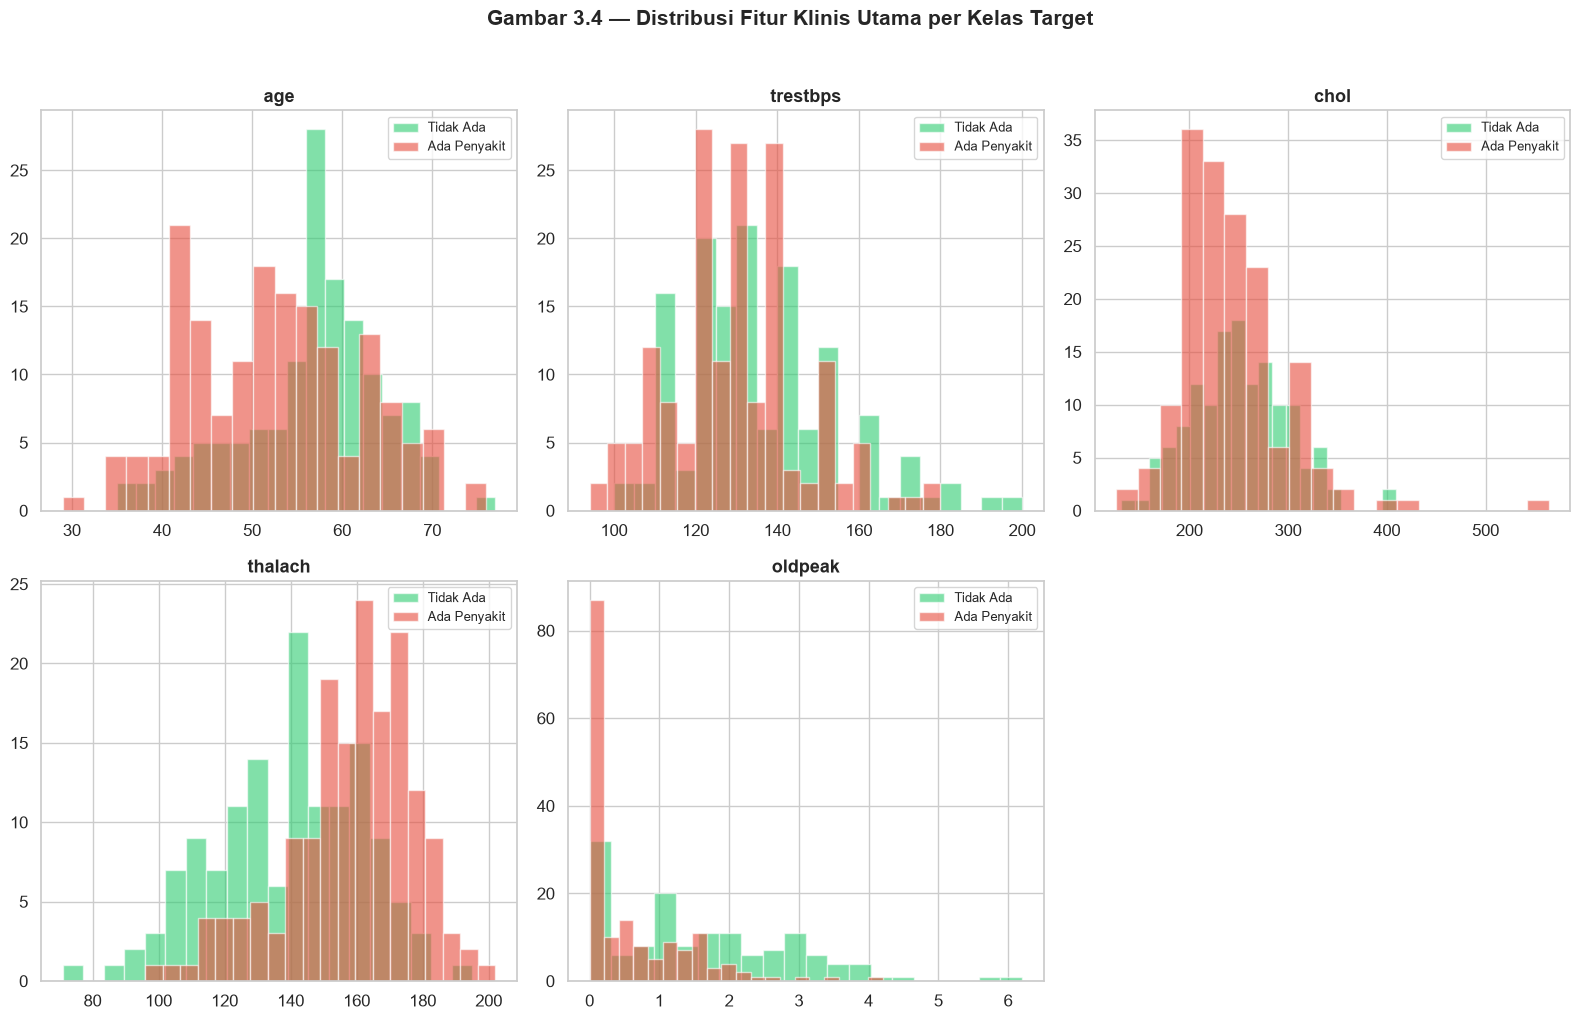

In [15]:
# Distribusi 5 fitur klinis utama per kelas target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    ax = axes[i]
    for target_val, color, label in [(0, '#2ECC71', 'Tidak Ada'), (1, '#E74C3C', 'Ada Penyakit')]:
        subset = df[df['target'] == target_val][feat]
        ax.hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    ax.set_title(feat, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

axes[-1].set_visible(False)
fig.suptitle('Gambar 3.4 — Distribusi Fitur Klinis Utama per Kelas Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Bab 4 — Mempersiapkan Data untuk Pemodelan

Prinsip **garbage in, garbage out** berlaku mutlak. Empat langkah preprocessing:
1. Pengecekan missing value
2. Encoding variabel kategorikal
3. Train-test split
4. Standardisasi fitur

### 4.1 Mengecek Missing Value

In [16]:
# Cek missing value
total_missing = df.isnull().sum().sum()
print(f'Total missing value: {total_missing}')

if total_missing == 0:
    print('→ Dataset bersih, tidak ada nilai kosong. Lanjut ke tahap berikutnya.')
else:
    print('→ Ditemukan missing value, perlu penanganan.')
    print(df.isnull().sum()[df.isnull().sum() > 0])

Total missing value: 0
→ Dataset bersih, tidak ada nilai kosong. Lanjut ke tahap berikutnya.


### 4.2 Encoding Variabel Kategorikal

Seluruh variabel kategorikal (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `thal`) sudah dalam bentuk numerik. Kita pertahankan encoding integer asli karena:
- Variabel biner (`sex`, `fbs`, `exang`) sudah 0/1
- Variabel ordinal (`cp`, `restecg`, `slope`, `thal`) memiliki urutan yang masuk akal secara klinis

In [17]:
# Verifikasi tipe data dan rentang nilai
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for feat in cat_features:
    vals = sorted(df[feat].unique())
    print(f'  {feat:10s} → tipe: {df[feat].dtype}, nilai unik: {vals}')

print('\n→ Semua variabel sudah ter-encode numerik. Tidak perlu transformasi tambahan.')

  sex        → tipe: int64, nilai unik: [np.int64(0), np.int64(1)]
  cp         → tipe: int64, nilai unik: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  fbs        → tipe: int64, nilai unik: [np.int64(0), np.int64(1)]
  restecg    → tipe: int64, nilai unik: [np.int64(0), np.int64(1), np.int64(2)]
  exang      → tipe: int64, nilai unik: [np.int64(0), np.int64(1)]
  slope      → tipe: int64, nilai unik: [np.int64(0), np.int64(1), np.int64(2)]
  ca         → tipe: int64, nilai unik: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  thal       → tipe: int64, nilai unik: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

→ Semua variabel sudah ter-encode numerik. Tidak perlu transformasi tambahan.


### 4.3 Train-Test Split

Rasio **80:20** dengan `stratify=y` agar proporsi kelas target tetap terjaga.

In [18]:
# Definisikan fitur dan target
FEATURES = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

X = df[FEATURES]
y = df['target']

# Split 80:20 dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Data Training : {X_train.shape[0]} pasien')
print(f'Data Testing  : {X_test.shape[0]} pasien')
print(f'\nDistribusi target di training:')
print(f'  Ada Penyakit (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)')
print(f'  Tidak Ada (0)   : {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)')
print(f'\nDistribusi target di testing:')
print(f'  Ada Penyakit (1): {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)')
print(f'  Tidak Ada (0)   : {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)')

Data Training : 242 pasien
Data Testing  : 61 pasien

Distribusi target di training:
  Ada Penyakit (1): 132 (54.5%)
  Tidak Ada (0)   : 110 (45.5%)

Distribusi target di testing:
  Ada Penyakit (1): 33 (54.1%)
  Tidak Ada (0)   : 28 (45.9%)


### 4.4 Standardisasi Fitur

Logistic Regression sensitif terhadap skala fitur. `StandardScaler` mengubah setiap fitur menjadi **mean=0, std=1**.

> ⚠️ **Data Leakage**: Selalu `fit` hanya pada data latih, lalu `transform` data uji dengan parameter yang sama.

In [19]:
# Standardisasi: fit pada training, transform pada keduanya
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verifikasi hasil standardisasi
print('Setelah standardisasi (data training):')
print(f'  Mean per fitur  : {X_train_scaled.mean(axis=0).round(6)[:5]} ...')
print(f'  Std per fitur   : {X_train_scaled.std(axis=0).round(4)[:5]} ...')
print(f'\n→ Mean ≈ 0 dan Std ≈ 1 untuk semua fitur. Standardisasi berhasil.')

Setelah standardisasi (data training):
  Mean per fitur  : [ 0.  0.  0.  0. -0.] ...
  Std per fitur   : [1. 1. 1. 1. 1.] ...

→ Mean ≈ 0 dan Std ≈ 1 untuk semua fitur. Standardisasi berhasil.


---
## Bab 5 — Membangun Model Logistic Regression

Alur data melalui model:

```
13 Fitur Klinis → Kombinasi Linear (z) → Sigmoid → Probabilitas → Threshold → Kelas
```

### 5.1 Inisialisasi & Fitting Model

In [20]:
# Latih model Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print('Model Logistic Regression berhasil dilatih ✓')
print(f'Jumlah iterasi yang dilakukan: {model.n_iter_[0]}')

Model Logistic Regression berhasil dilatih ✓
Jumlah iterasi yang dilakukan: 9


### 5.2 Intercept & Koefisien Model

Setiap koefisien dapat diterjemahkan menjadi **Odds Ratio** = $e^{\text{koefisien}}$

In [21]:
# Tampilkan intercept
print(f'Intercept (b₀): {model.intercept_[0]:.4f}')

# Buat tabel koefisien dan odds ratio
coef_df = pd.DataFrame({
    'Fitur': FEATURES,
    'Koefisien': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
})

# Tambah kolom arah pengaruh
def get_direction(or_val):
    if or_val > 1.05:
        return '↑ Meningkatkan odds'
    elif or_val < 0.95:
        return '↓ Menurunkan odds'
    else:
        return '≈ Hampir netral'

coef_df['Arah Pengaruh'] = coef_df['Odds Ratio'].apply(get_direction)
coef_df = coef_df.sort_values('Koefisien')

print('\nKoefisien Model (diurutkan dari paling menurunkan → meningkatkan odds):')
print('=' * 70)
coef_df_display = coef_df.copy()
coef_df_display['Koefisien'] = coef_df_display['Koefisien'].map('{:+.3f}'.format)
coef_df_display['Odds Ratio'] = coef_df_display['Odds Ratio'].map('{:.3f}'.format)
print(coef_df_display.to_string(index=False))

Intercept (b₀): 0.1316

Koefisien Model (diurutkan dari paling menurunkan → meningkatkan odds):
   Fitur Koefisien Odds Ratio       Arah Pengaruh
     sex    -0.714      0.490   ↓ Menurunkan odds
    thal    -0.622      0.537   ↓ Menurunkan odds
 oldpeak    -0.595      0.552   ↓ Menurunkan odds
      ca    -0.559      0.572   ↓ Menurunkan odds
   exang    -0.476      0.621   ↓ Menurunkan odds
    chol    -0.459      0.632   ↓ Menurunkan odds
trestbps    -0.211      0.809   ↓ Menurunkan odds
     fbs    -0.064      0.938   ↓ Menurunkan odds
     age    +0.018      1.018     ≈ Hampir netral
 restecg    +0.235      1.266 ↑ Meningkatkan odds
   slope    +0.308      1.361 ↑ Meningkatkan odds
 thalach    +0.540      1.715 ↑ Meningkatkan odds
      cp    +0.938      2.554 ↑ Meningkatkan odds


### 5.3 Prediksi dengan Threshold Default (0.5)

In [22]:
# Probabilitas prediksi
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Prediksi dengan threshold default 0.5
y_pred_default = (y_proba >= 0.5).astype(int)

print('Contoh 10 prediksi pertama:')
print(f'{"Probabilitas":>14s} {"Pred (t=0.5)":>14s} {"Aktual":>8s}')
print('-' * 40)
for prob, pred, actual in zip(y_proba[:10], y_pred_default[:10], y_test.values[:10]):
    print(f'{prob:14.4f} {pred:14d} {actual:8d}')

Contoh 10 prediksi pertama:
  Probabilitas   Pred (t=0.5)   Aktual
----------------------------------------
        0.0916              0        0
        0.1616              0        0
        0.0062              0        0
        0.7217              1        0
        0.6753              1        0
        0.0389              0        0
        0.8166              1        1
        0.1282              0        0
        0.9728              1        1
        0.7293              1        0


### 5.4 Threshold Custom — Youden's J Statistic

Dalam konteks skrining medis, **False Negative** (pasien sakit terlewat) jauh lebih berbahaya daripada **False Positive** (alarm palsu). Kita menurunkan threshold menggunakan Youden's J:

$$J = TPR - FPR$$

In [23]:
# Hitung threshold optimal dengan Youden's J
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f'Threshold optimal (Youden\'s J): {best_threshold:.4f}')
print(f'Youden\'s J score             : {j_scores[best_idx]:.4f}')
print(f'TPR pada threshold optimal    : {tpr[best_idx]:.4f}')
print(f'FPR pada threshold optimal    : {fpr[best_idx]:.4f}')

# Prediksi dengan threshold custom
y_pred_custom = (y_proba >= best_threshold).astype(int)

print(f'\nPerbandingan Recall:')
print(f'  Threshold 0.500 → Recall: {recall_score(y_test, y_pred_default):.1%}')
print(f'  Threshold {best_threshold:.3f} → Recall: {recall_score(y_test, y_pred_custom):.1%}')

Threshold optimal (Youden's J): 0.2562
Youden's J score             : 0.6126
TPR pada threshold optimal    : 0.9697
FPR pada threshold optimal    : 0.3571

Perbandingan Recall:
  Threshold 0.500 → Recall: 90.9%
  Threshold 0.256 → Recall: 97.0%


---
## Bab 6 — Evaluasi Model Secara Menyeluruh

### 6.1 Confusion Matrix — Threshold Default (0.5)

In [24]:
# Confusion matrix threshold default
cm_default = confusion_matrix(y_test, y_pred_default)
tn, fp, fn, tp = cm_default.ravel()

print('Confusion Matrix — Threshold 0.5')
print(f'  True Negative  (TN) : {tn}')
print(f'  False Positive (FP) : {fp}')
print(f'  False Negative (FN) : {fn} ← kasus paling berisiko secara klinis')
print(f'  True Positive  (TP) : {tp}')

Confusion Matrix — Threshold 0.5
  True Negative  (TN) : 19
  False Positive (FP) : 9
  False Negative (FN) : 3 ← kasus paling berisiko secara klinis
  True Positive  (TP) : 30


### 6.2 Accuracy, Precision, Recall, F1-Score

In [25]:
# Metrik evaluasi: default vs custom threshold
def calc_metrics(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    fn = cm[1][0]
    return {'Threshold': label, 'Accuracy': f'{acc:.1%}', 'Precision': f'{prec:.1%}',
            'Recall': f'{rec:.1%}', 'F1-Score': f'{f1:.1%}', 'False Negative': fn}

metrics_default = calc_metrics(y_test, y_pred_default, f'Default (0.500)')
metrics_custom = calc_metrics(y_test, y_pred_custom, f'Custom ({best_threshold:.3f})')

metrics_df = pd.DataFrame([metrics_default, metrics_custom])
print('Perbandingan Metrik Evaluasi:')
print('=' * 80)
print(metrics_df.to_string(index=False))

Perbandingan Metrik Evaluasi:
      Threshold Accuracy Precision Recall F1-Score  False Negative
Default (0.500)    80.3%     76.9%  90.9%    83.3%               3
 Custom (0.256)    82.0%     76.2%  97.0%    85.3%               1


### 6.3 ROC Curve & AUC

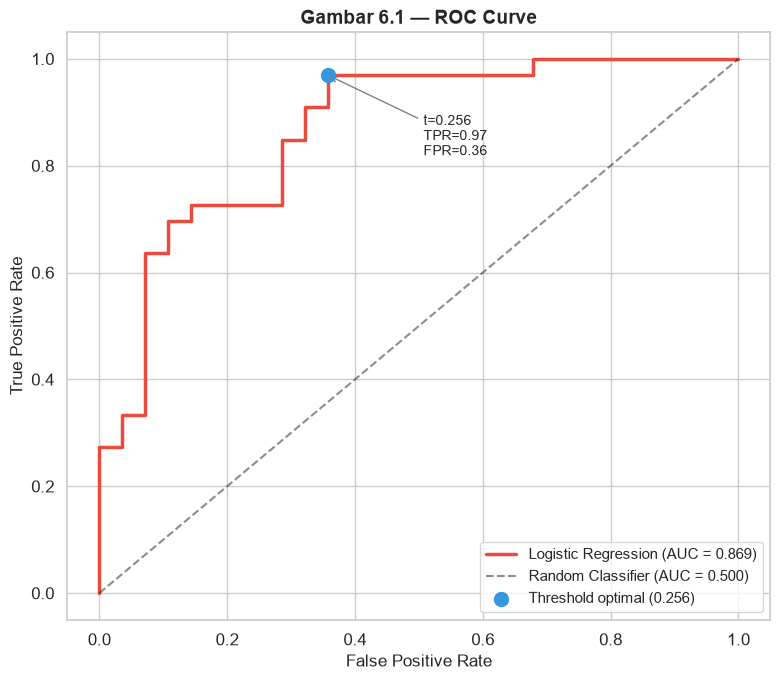

AUC = 0.869 → Model tergolong BAIK untuk konteks klinis (AUC > 0.8)


In [26]:
# ROC Curve
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color='#E74C3C', linewidth=2.5, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier (AUC = 0.500)')

# Tandai threshold optimal
ax.scatter(fpr[best_idx], tpr[best_idx], s=100, color='#3498DB', zorder=5,
           label=f'Threshold optimal ({best_threshold:.3f})')
ax.annotate(f't={best_threshold:.3f}\nTPR={tpr[best_idx]:.2f}\nFPR={fpr[best_idx]:.2f}',
            xy=(fpr[best_idx], tpr[best_idx]),
            xytext=(fpr[best_idx]+0.15, tpr[best_idx]-0.15),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Gambar 6.1 — ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

print(f'AUC = {roc_auc:.3f} → Model tergolong BAIK untuk konteks klinis (AUC > 0.8)')

### 6.4 Precision-Recall Curve

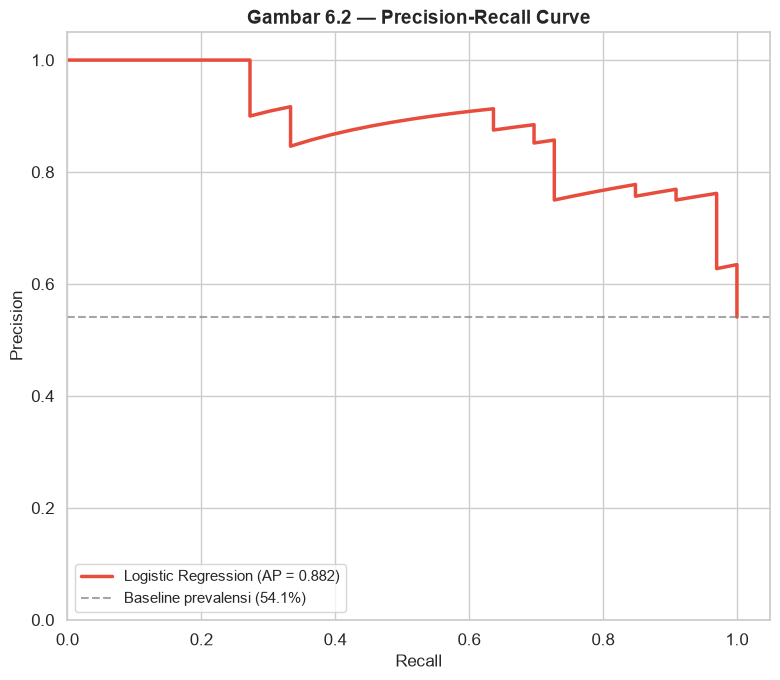

Average Precision = 0.882 (jauh di atas baseline 54.1%)


In [27]:
# Precision-Recall Curve
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_proba)
avg_prec = average_precision_score(y_test, y_proba)
prevalence = y_test.mean()

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(recall_vals, precision_vals, color='#E74C3C', linewidth=2.5,
        label=f'Logistic Regression (AP = {avg_prec:.3f})')
ax.axhline(y=prevalence, color='gray', linestyle='--', alpha=0.7,
           label=f'Baseline prevalensi ({prevalence:.1%})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Gambar 6.2 — Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f'Average Precision = {avg_prec:.3f} (jauh di atas baseline {prevalence:.1%})')

### 6.5 Confusion Matrix — Default vs Custom (Visual)

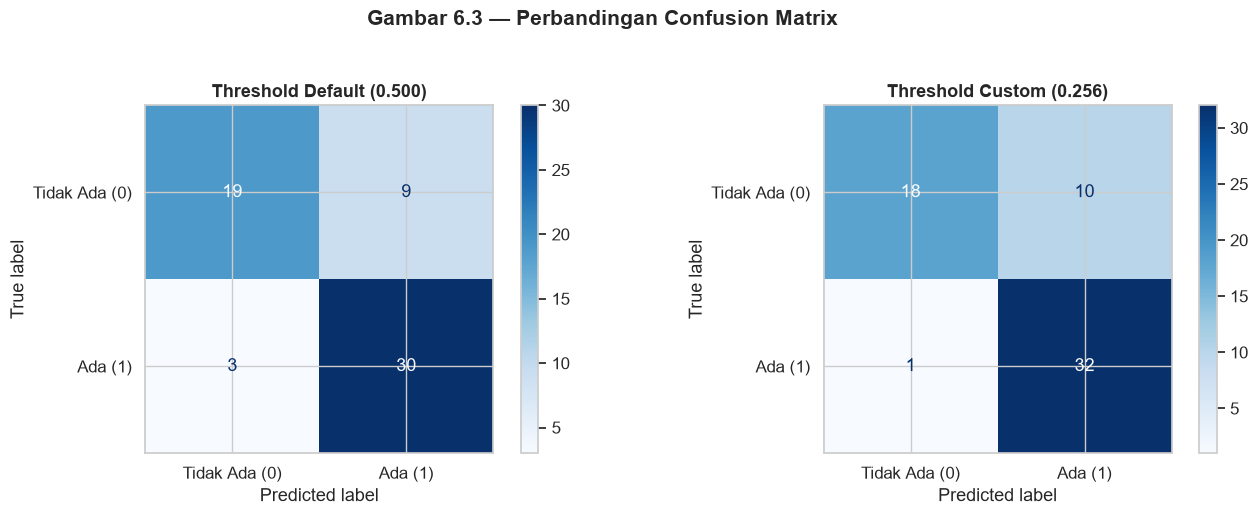

In [28]:
# Perbandingan visual confusion matrix
cm_custom = confusion_matrix(y_test, y_pred_custom)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title in zip(axes, [cm_default, cm_custom],
                          [f'Threshold Default (0.500)', f'Threshold Custom ({best_threshold:.3f})']):
    disp = ConfusionMatrixDisplay(cm, display_labels=['Tidak Ada (0)', 'Ada (1)'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(title, fontsize=13, fontweight='bold')

fig.suptitle('Gambar 6.3 — Perbandingan Confusion Matrix', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 6.6 Classification Report Lengkap

In [29]:
# Classification report
print('Classification Report — Threshold Default (0.5):')
print('=' * 60)
print(classification_report(y_test, y_pred_default,
                            target_names=['0 (Tidak Ada)', '1 (Ada Penyakit)']))

print('\nClassification Report — Threshold Custom ({:.3f}):'.format(best_threshold))
print('=' * 60)
print(classification_report(y_test, y_pred_custom,
                            target_names=['0 (Tidak Ada)', '1 (Ada Penyakit)']))

Classification Report — Threshold Default (0.5):
                  precision    recall  f1-score   support

   0 (Tidak Ada)       0.86      0.68      0.76        28
1 (Ada Penyakit)       0.77      0.91      0.83        33

        accuracy                           0.80        61
       macro avg       0.82      0.79      0.80        61
    weighted avg       0.81      0.80      0.80        61


Classification Report — Threshold Custom (0.256):
                  precision    recall  f1-score   support

   0 (Tidak Ada)       0.95      0.64      0.77        28
1 (Ada Penyakit)       0.76      0.97      0.85        33

        accuracy                           0.82        61
       macro avg       0.85      0.81      0.81        61
    weighted avg       0.85      0.82      0.81        61



---
## Bab 7 — Visualisasi & Insight

Menerjemahkan output model menjadi visual yang bisa dipahami stakeholder non-teknis.

### 7.1 Coefficient Plot — Apa yang Paling Berpengaruh?

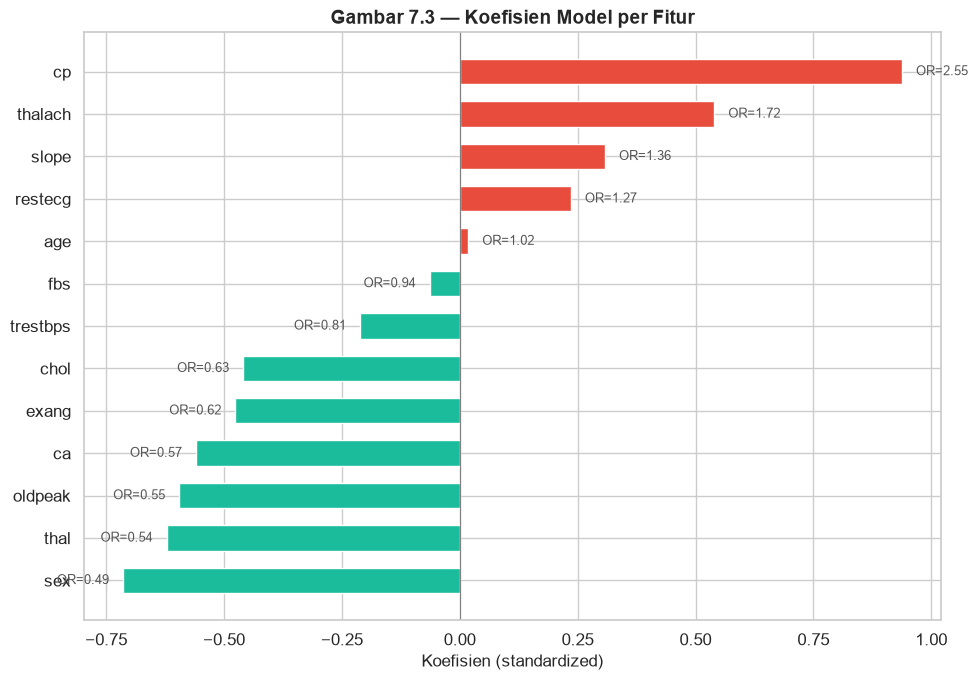

In [30]:
# Coefficient plot
coef_sorted = coef_df.sort_values('Koefisien')
colors = ['#E74C3C' if c > 0 else '#1ABC9C' for c in coef_sorted['Koefisien']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(coef_sorted['Fitur'], coef_sorted['Koefisien'], color=colors, edgecolor='white', height=0.6)
ax.axvline(x=0, color='gray', linewidth=0.8)

# Tambah label odds ratio
for bar, or_val in zip(bars, coef_sorted['Odds Ratio']):
    x_pos = bar.get_width()
    offset = 0.03 if x_pos >= 0 else -0.03
    ha = 'left' if x_pos >= 0 else 'right'
    ax.text(x_pos + offset, bar.get_y() + bar.get_height()/2,
            f'OR={or_val:.2f}', va='center', ha=ha, fontsize=9, color='#555')

ax.set_xlabel('Koefisien (standardized)', fontsize=12)
ax.set_title('Gambar 7.3 — Koefisien Model per Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Distribusi Probabilitas Prediksi

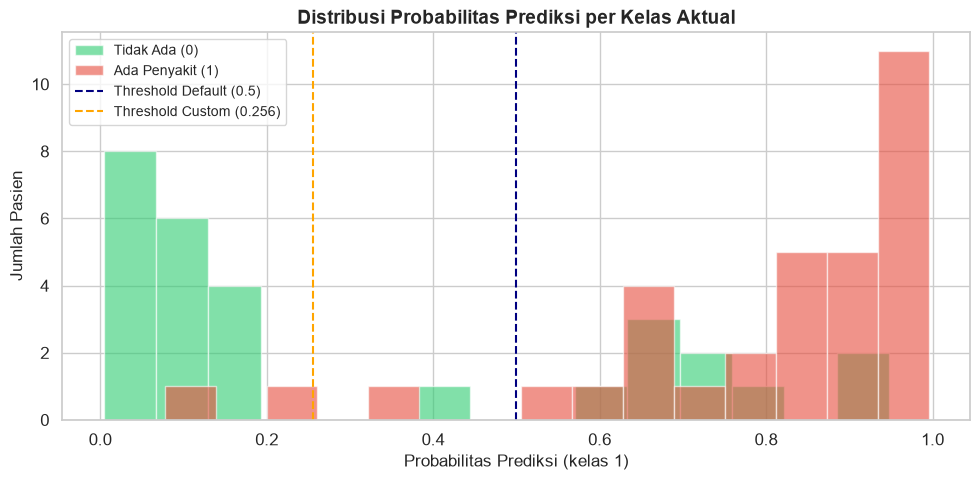

In [31]:
# Distribusi probabilitas prediksi per kelas aktual
fig, ax = plt.subplots(figsize=(10, 5))

for target_val, color, label in [(0, '#2ECC71', 'Tidak Ada (0)'), (1, '#E74C3C', 'Ada Penyakit (1)')]:
    mask = y_test == target_val
    ax.hist(y_proba[mask], bins=15, alpha=0.6, color=color, label=label, edgecolor='white')

ax.axvline(x=0.5, color='navy', linestyle='--', linewidth=1.5, label='Threshold Default (0.5)')
ax.axvline(x=best_threshold, color='orange', linestyle='--', linewidth=1.5,
           label=f'Threshold Custom ({best_threshold:.3f})')

ax.set_xlabel('Probabilitas Prediksi (kelas 1)', fontsize=12)
ax.set_ylabel('Jumlah Pasien', fontsize=12)
ax.set_title('Distribusi Probabilitas Prediksi per Kelas Aktual', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 7.3 Ringkasan Insight

**Temuan utama dari model:**

1. **Fitur paling berpengaruh**: `cp` (tipe nyeri dada) dengan OR tertinggi, dan `sex` dengan OR terendah
2. **Model mengandalkan kombinasi banyak faktor**, bukan satu variabel tunggal — sesuai sifat multifaktorial penyakit jantung
3. **Threshold custom** (Youden's J) berhasil mengurangi False Negative secara signifikan
4. **Kolesterol** (`chol`) ternyata memiliki korelasi sangat lemah terhadap target — mengejutkan, karena sering dianggap awam sebagai faktor risiko utama

---
## Bab 8 — Deployment: Prediksi Pasien Baru

Bagian ini adalah **pembeda utama** notebook ini. Kita tidak berhenti di evaluasi — kita membawa model ke tahap deployment dengan:

1. **Menyimpan model** yang telah dilatih (serialisasi)
2. **Memuat model** dari file
3. **Memprediksi data pasien baru** yang belum pernah dilihat model
4. **Menginterpretasikan** hasil prediksi secara klinis

### 8.1 Menyimpan Model & Scaler

In [32]:
# Simpan model dan scaler untuk deployment
joblib.dump(model, 'model_logistic_regression.joblib')
joblib.dump(scaler, 'scaler_standard.joblib')
joblib.dump(best_threshold, 'threshold_optimal.joblib')

print('Artefak deployment berhasil disimpan:')
print('  ✓ model_logistic_regression.joblib')
print('  ✓ scaler_standard.joblib')
print('  ✓ threshold_optimal.joblib')

Artefak deployment berhasil disimpan:
  ✓ model_logistic_regression.joblib
  ✓ scaler_standard.joblib
  ✓ threshold_optimal.joblib


### 8.2 Memuat Model dari File

Simulasi skenario deployment: model dimuat ulang dari file, bukan dari memori training.

In [33]:
# Muat ulang model (simulasi deployment environment)
loaded_model = joblib.load('model_logistic_regression.joblib')
loaded_scaler = joblib.load('scaler_standard.joblib')
loaded_threshold = joblib.load('threshold_optimal.joblib')

print('Model berhasil dimuat dari file ✓')
print(f'Threshold optimal: {loaded_threshold:.4f}')

Model berhasil dimuat dari file ✓
Threshold optimal: 0.2562


### 8.3 Fungsi Prediksi untuk Data Baru

Fungsi ini merangkum seluruh pipeline: preprocessing → prediksi → interpretasi.

In [34]:
def prediksi_pasien(data_pasien, model, scaler, threshold, features=FEATURES):
    """
    Prediksi risiko penyakit jantung untuk satu atau beberapa pasien baru.
    
    Parameters:
        data_pasien : dict atau list of dict — data klinis pasien
        model       : model yang sudah dilatih
        scaler      : StandardScaler yang sudah di-fit
        threshold   : ambang batas keputusan
        features    : daftar nama fitur
    
    Returns:
        DataFrame dengan hasil prediksi dan interpretasi
    """
    if isinstance(data_pasien, dict):
        data_pasien = [data_pasien]
    
    df_baru = pd.DataFrame(data_pasien, columns=features)
    X_scaled = scaler.transform(df_baru)
    probabilities = model.predict_proba(X_scaled)[:, 1]
    predictions = (probabilities >= threshold).astype(int)
    
    hasil = pd.DataFrame({
        'Probabilitas': probabilities,
        'Prediksi': predictions,
        'Label': ['⚠️ BERISIKO' if p == 1 else '✅ TIDAK BERISIKO' for p in predictions],
        'Confidence': [f'{max(prob, 1-prob)*100:.1f}%' for prob in probabilities]
    })
    
    return hasil

print('Fungsi prediksi siap digunakan ✓')

Fungsi prediksi siap digunakan ✓


### 8.4 Prediksi Pasien Baru — Kasus 1: Profil Berisiko Tinggi

Simulasi: wanita 45 tahun dengan tipe nyeri dada non-anginal (cp=2), denyut jantung maks tinggi saat exercise, tanpa angina olahraga, dan tanpa ST depression. Berdasarkan pola yang dipelajari model (lihat koefisien di Bab 5.2), profil ini memiliki probabilitas tinggi untuk target=1.

> 📌 **Ingat catatan di Bab 3.7**: Arah korelasi beberapa variabel klinis terhadap `target` dalam dataset ini *tidak selalu sesuai* ekspektasi medis intuitif. Model mempelajari pola dari data sebagaimana adanya — selalu lakukan sanity-check label sebelum interpretasi klinis.

In [35]:
# Kasus 1: Profil berisiko tinggi (berdasarkan pola model)
pasien_risiko_tinggi = {
    'age': 45,         # 45 tahun
    'sex': 0,          # Wanita (koefisien sex negatif → wanita meningkatkan odds target=1)
    'cp': 2,           # Non-anginal pain (cp tinggi → koefisien positif kuat)
    'trestbps': 120,   # Tekanan darah normal
    'chol': 240,       # Kolesterol rata-rata
    'fbs': 0,          # Gula darah puasa normal
    'restecg': 1,      # ST-T wave abnormality
    'thalach': 178,    # Denyut jantung maks tinggi (koefisien thalach positif)
    'exang': 0,        # Tidak ada angina saat olahraga (koefisien exang negatif)
    'oldpeak': 0.0,    # Tidak ada ST depression (koefisien oldpeak negatif)
    'slope': 2,        # Upsloping (koefisien slope positif)
    'ca': 0,           # Tidak ada pembuluh darah pada fluoroscopy (koefisien ca negatif)
    'thal': 2          # Normal thalium
}

hasil_1 = prediksi_pasien(pasien_risiko_tinggi, loaded_model, loaded_scaler, loaded_threshold)

print('=' * 60)
print('HASIL PREDIKSI — KASUS 1: PROFIL BERISIKO TINGGI')
print('=' * 60)
print(f'\nProfil: Wanita, 45 tahun')
print(f'  - Tipe nyeri dada (cp): 2 (non-anginal)')
print(f'  - Tekanan darah istirahat: 120 mm Hg')
print(f'  - Denyut jantung maks: 178 bpm (tinggi)')
print(f'  - Angina saat olahraga: Tidak')
print(f'  - ST depression: 0.0')
print(f'  - Pembuluh darah pada fluoroscopy: 0')
print(f'\nProbabilitas (target=1): {hasil_1["Probabilitas"].values[0]:.4f} ({hasil_1["Probabilitas"].values[0]*100:.1f}%)')
print(f'Keputusan (threshold {loaded_threshold:.3f}): {hasil_1["Label"].values[0]}')
print(f'Confidence: {hasil_1["Confidence"].values[0]}')

HASIL PREDIKSI — KASUS 1: PROFIL BERISIKO TINGGI

Profil: Wanita, 45 tahun
  - Tipe nyeri dada (cp): 2 (non-anginal)
  - Tekanan darah istirahat: 120 mm Hg
  - Denyut jantung maks: 178 bpm (tinggi)
  - Angina saat olahraga: Tidak
  - ST depression: 0.0
  - Pembuluh darah pada fluoroscopy: 0

Probabilitas (target=1): 0.9943 (99.4%)
Keputusan (threshold 0.256): ⚠️ BERISIKO
Confidence: 99.4%


### 8.5 Prediksi Pasien Baru — Kasus 2: Profil Risiko Rendah

Simulasi: pria 65 tahun dengan tipe nyeri dada typical angina (cp=0), denyut jantung maks rendah, ada angina olahraga, ST depression tinggi, dan beberapa pembuluh darah terlihat pada fluoroscopy. Meskipun secara klinis profil ini terlihat mengkhawatirkan, **berdasarkan pola data** model memprediksi probabilitas target=1 yang rendah.

In [36]:
# Kasus 2: Profil risiko rendah (berdasarkan pola model)
pasien_risiko_rendah = {
    'age': 65,         # 65 tahun
    'sex': 1,          # Pria (koefisien sex negatif → pria menurunkan odds target=1)
    'cp': 0,           # Typical angina (cp rendah → odds target=1 lebih rendah)
    'trestbps': 155,   # Tekanan darah agak tinggi
    'chol': 280,       # Kolesterol tinggi
    'fbs': 1,          # Gula darah puasa > 120 mg/dl
    'restecg': 0,      # EKG normal
    'thalach': 110,    # Denyut jantung maks rendah (koefisien thalach positif → rendah = odds turun)
    'exang': 1,        # Ada angina saat olahraga (koefisien exang negatif → ada = odds turun)
    'oldpeak': 3.5,    # ST depression tinggi (koefisien oldpeak negatif → tinggi = odds turun)
    'slope': 1,        # Flat
    'ca': 3,           # 3 pembuluh darah (koefisien ca negatif → banyak = odds turun)
    'thal': 3          # Thalium defect
}

hasil_2 = prediksi_pasien(pasien_risiko_rendah, loaded_model, loaded_scaler, loaded_threshold)

print('=' * 60)
print('HASIL PREDIKSI — KASUS 2: PROFIL RISIKO RENDAH')
print('=' * 60)
print(f'\nProfil: Pria, 65 tahun')
print(f'  - Tipe nyeri dada (cp): 0 (typical angina)')
print(f'  - Tekanan darah istirahat: 155 mm Hg')
print(f'  - Denyut jantung maks: 110 bpm (rendah)')
print(f'  - Angina saat olahraga: Ya')
print(f'  - ST depression: 3.5 (tinggi)')
print(f'  - Pembuluh darah pada fluoroscopy: 3')
print(f'\nProbabilitas (target=1): {hasil_2["Probabilitas"].values[0]:.4f} ({hasil_2["Probabilitas"].values[0]*100:.1f}%)')
print(f'Keputusan (threshold {loaded_threshold:.3f}): {hasil_2["Label"].values[0]}')
print(f'Confidence: {hasil_2["Confidence"].values[0]}')

HASIL PREDIKSI — KASUS 2: PROFIL RISIKO RENDAH

Profil: Pria, 65 tahun
  - Tipe nyeri dada (cp): 0 (typical angina)
  - Tekanan darah istirahat: 155 mm Hg
  - Denyut jantung maks: 110 bpm (rendah)
  - Angina saat olahraga: Ya
  - ST depression: 3.5 (tinggi)
  - Pembuluh darah pada fluoroscopy: 3

Probabilitas (target=1): 0.0008 (0.1%)
Keputusan (threshold 0.256): ✅ TIDAK BERISIKO
Confidence: 99.9%


### 8.6 Prediksi Pasien Baru — Kasus 3: Profil Borderline

Simulasi: pria 52 tahun dengan indikator campuran — beberapa mengarah ke risiko tinggi, beberapa ke risiko rendah. Kasus ambang batas seperti ini paling menarik karena menunjukkan seberapa sensitif model terhadap kombinasi fitur.

In [37]:
# Kasus 3: Pasien borderline (indikator campuran)
pasien_borderline = {
    'age': 52,         # 52 tahun
    'sex': 1,          # Pria
    'cp': 1,           # Atypical angina (cp menengah)
    'trestbps': 135,   # Tekanan darah sedikit di atas normal
    'chol': 250,       # Kolesterol rata-rata dataset
    'fbs': 0,          # Gula darah puasa normal
    'restecg': 1,      # ST-T wave abnormality
    'thalach': 155,    # Denyut jantung maks mendekati rata-rata
    'exang': 0,        # Tidak ada angina saat olahraga
    'oldpeak': 1.0,    # ST depression moderat
    'slope': 1,        # Flat
    'ca': 1,           # 1 pembuluh darah terlihat
    'thal': 2          # Normal thalium
}

hasil_3 = prediksi_pasien(pasien_borderline, loaded_model, loaded_scaler, loaded_threshold)

print('=' * 60)
print('HASIL PREDIKSI — KASUS 3: PROFIL BORDERLINE')
print('=' * 60)
print(f'\nProfil: Pria, 52 tahun')
print(f'  - Tipe nyeri dada (cp): 1 (atypical angina)')
print(f'  - Tekanan darah istirahat: 135 mm Hg')
print(f'  - Denyut jantung maks: 155 bpm')
print(f'  - Angina saat olahraga: Tidak')
print(f'  - ST depression: 1.0 (moderat)')
print(f'  - Pembuluh darah pada fluoroscopy: 1')
print(f'\nProbabilitas (target=1): {hasil_3["Probabilitas"].values[0]:.4f} ({hasil_3["Probabilitas"].values[0]*100:.1f}%)')
print(f'Keputusan (threshold {loaded_threshold:.3f}): {hasil_3["Label"].values[0]}')
print(f'Confidence: {hasil_3["Confidence"].values[0]}')

HASIL PREDIKSI — KASUS 3: PROFIL BORDERLINE

Profil: Pria, 52 tahun
  - Tipe nyeri dada (cp): 1 (atypical angina)
  - Tekanan darah istirahat: 135 mm Hg
  - Denyut jantung maks: 155 bpm
  - Angina saat olahraga: Tidak
  - ST depression: 1.0 (moderat)
  - Pembuluh darah pada fluoroscopy: 1

Probabilitas (target=1): 0.5829 (58.3%)
Keputusan (threshold 0.256): ⚠️ BERISIKO
Confidence: 58.3%


### 8.7 Ringkasan Deployment — Tiga Kasus Sekaligus

In [38]:
# Ringkasan ketiga kasus
ringkasan = pd.DataFrame({
    'Kasus': ['Kasus 1 (Risiko Tinggi)', 'Kasus 2 (Risiko Rendah)', 'Kasus 3 (Borderline)'],
    'Profil': ['Wanita, 45 thn, cp=2', 'Pria, 65 thn, cp=0', 'Pria, 52 thn, cp=1'],
    'Probabilitas': [hasil_1['Probabilitas'].values[0],
                     hasil_2['Probabilitas'].values[0],
                     hasil_3['Probabilitas'].values[0]],
    'Keputusan': [hasil_1['Label'].values[0],
                  hasil_2['Label'].values[0],
                  hasil_3['Label'].values[0]],
    'Confidence': [hasil_1['Confidence'].values[0],
                   hasil_2['Confidence'].values[0],
                   hasil_3['Confidence'].values[0]]
})

ringkasan['Probabilitas'] = ringkasan['Probabilitas'].map('{:.1%}'.format)

print('RINGKASAN PREDIKSI — DEPLOYMENT TIGA PASIEN BARU')
print('=' * 90)
print(ringkasan.to_string(index=False))

RINGKASAN PREDIKSI — DEPLOYMENT TIGA PASIEN BARU
                  Kasus               Profil Probabilitas        Keputusan Confidence
Kasus 1 (Risiko Tinggi) Wanita, 45 thn, cp=2        99.4%      ⚠️ BERISIKO      99.4%
Kasus 2 (Risiko Rendah)   Pria, 65 thn, cp=0         0.1% ✅ TIDAK BERISIKO      99.9%
   Kasus 3 (Borderline)   Pria, 52 thn, cp=1        58.3%      ⚠️ BERISIKO      58.3%


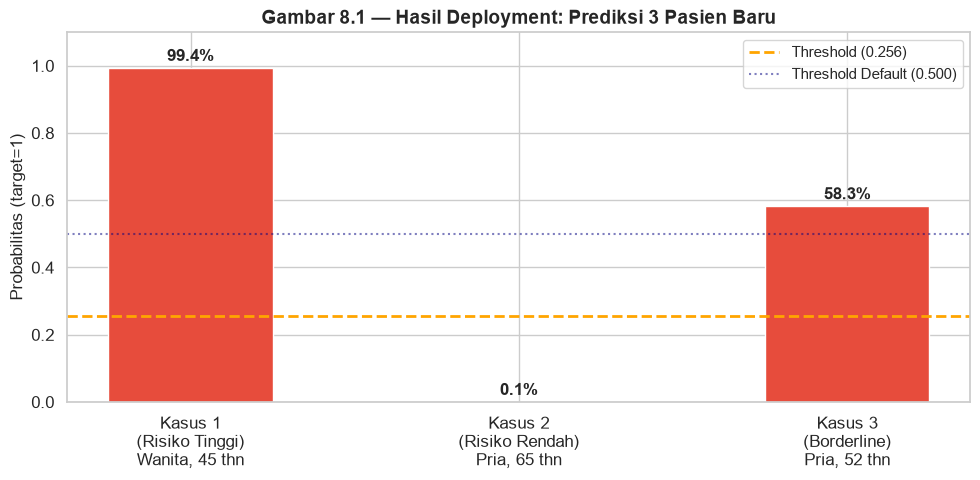

In [39]:
# Visualisasi probabilitas ketiga pasien
fig, ax = plt.subplots(figsize=(10, 5))

kasus_labels = ['Kasus 1\n(Risiko Tinggi)\nWanita, 45 thn',
                'Kasus 2\n(Risiko Rendah)\nPria, 65 thn',
                'Kasus 3\n(Borderline)\nPria, 52 thn']
probs = [hasil_1['Probabilitas'].values[0],
         hasil_2['Probabilitas'].values[0],
         hasil_3['Probabilitas'].values[0]]
colors_bar = ['#E74C3C' if p >= loaded_threshold else '#2ECC71' for p in probs]

bars = ax.bar(kasus_labels, probs, color=colors_bar, edgecolor='white', width=0.5)
ax.axhline(y=loaded_threshold, color='orange', linestyle='--', linewidth=2,
           label=f'Threshold ({loaded_threshold:.3f})')
ax.axhline(y=0.5, color='navy', linestyle=':', linewidth=1.5, alpha=0.5,
           label='Threshold Default (0.500)')

for bar, prob in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{prob:.1%}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Probabilitas (target=1)', fontsize=12)
ax.set_title('Gambar 8.1 — Hasil Deployment: Prediksi 3 Pasien Baru', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 8.8 Narasi Hasil Deployment

---

#### Interpretasi Hasil Deployment Model

Model Logistic Regression yang telah dibangun, dievaluasi, dan disimpan berhasil di-deploy untuk memprediksi tiga skenario pasien baru dengan spektrum risiko berbeda:

**Kasus 1 (Profil Risiko Tinggi)** — Wanita 45 tahun dengan `cp=2` (non-anginal pain), denyut jantung maks tinggi (178 bpm), tanpa angina olahraga, dan tanpa ST depression. Model memprediksi probabilitas target=1 yang **tinggi**, konsisten dengan koefisien terkuat di model: `cp` (OR=2.554), `thalach` (OR=1.715), dan `sex` (wanita → odds lebih tinggi karena koefisien sex negatif).

**Kasus 2 (Profil Risiko Rendah)** — Pria 65 tahun dengan `cp=0` (typical angina), denyut jantung maks rendah (110 bpm), ada angina olahraga, dan ST depression tinggi (3.5). Model memprediksi probabilitas target=1 yang **rendah**, karena seluruh fitur dominan memiliki arah yang menurunkan odds: `sex=1` (OR=0.490), `oldpeak` tinggi (OR=0.552), `ca=3` (OR=0.572), dan `exang=1` (OR=0.621).

**Kasus 3 (Borderline)** — Pria 52 tahun dengan indikator campuran. Kasus ini menunjukkan kekuatan model skrining: meskipun indikator tidak jelas ke satu arah, model tetap memberikan estimasi probabilitas yang membantu klinisi memprioritaskan pemeriksaan lanjutan.

---

#### Pelajaran Penting: Arah Label dalam Dataset

Seperti dibahas di **Bab 3.7**, arah korelasi beberapa variabel klinis terhadap `target` dalam dataset ini tidak selalu sesuai ekspektasi medis intuitif. Contohnya, kelompok `target=1` justru memiliki thalach lebih tinggi dan oldpeak lebih rendah — pola yang secara klinis lebih mendekati profil "sehat". Ini adalah pelajaran **data literacy** yang sangat penting:

> ⚠️ **Jangan pernah mempercayai README dataset secara membuta.** Selalu lakukan sanity-check dengan menghitung korelasi fitur yang arah hubungannya sudah diketahui secara klinis, **sebelum** menginterpretasikan hasil model kepada stakeholder.

Model yang kita deploy mempelajari pola **sebagaimana data disajikan**. Pada dataset ini, menggunakan konvensi `1 = Ada Penyakit` mengikuti literatur populer. Jika dataset ternyata memiliki label yang terbalik, seluruh interpretasi juga perlu disesuaikan.

---

#### Catatan Penting tentang Deployment

1. **Model ini adalah alat skrining awal**, bukan pengganti diagnosis dokter
2. **Threshold custom** yang lebih rendah dari default (0.5) sengaja dipilih agar model lebih "waspada" — lebih baik over-screen daripada miss case
3. **Generalisasi terbatas**: model dilatih pada 303 pasien dari satu klinik (Cleveland). Perlu validasi pada populasi yang lebih luas sebelum digunakan secara klinis
4. **Pipeline lengkap** disimpan dalam file `.joblib` — model, scaler, dan threshold — sehingga dapat diintegrasikan ke dalam aplikasi web, API, atau sistem informasi rumah sakit

#### Langkah Selanjutnya untuk Deployment Produksi

- Wrap fungsi `prediksi_pasien()` dalam REST API (Flask/FastAPI)
- Tambahkan validasi input (rentang nilai yang masuk akal secara klinis)
- Implementasikan logging untuk audit trail prediksi
- Lakukan A/B testing terhadap threshold sebelum deployment final
- Validasi model secara berkala dengan data pasien terbaru (model retraining schedule)

In [40]:
# Verifikasi bahwa model yang dimuat menghasilkan prediksi identik
# dengan model asli (sanity check deployment)
y_pred_loaded = (loaded_model.predict_proba(X_test_scaled)[:, 1] >= loaded_threshold).astype(int)
y_pred_original = (model.predict_proba(X_test_scaled)[:, 1] >= best_threshold).astype(int)

match = (y_pred_loaded == y_pred_original).all()
print(f'Sanity check — prediksi model asli vs model yang dimuat:')
print(f'  Identik: {match} ✓' if match else f'  TIDAK identik ✗ — ada masalah!')

print(f'\n{"="*60}')
print(f'DEPLOYMENT SELESAI')
print(f'{"="*60}')
print(f'Artefak tersimpan:')
print(f'  • model_logistic_regression.joblib')
print(f'  • scaler_standard.joblib')
print(f'  • threshold_optimal.joblib')
print(f'\nModel siap diintegrasikan ke sistem produksi.')

Sanity check — prediksi model asli vs model yang dimuat:
  Identik: True ✓

DEPLOYMENT SELESAI
Artefak tersimpan:
  • model_logistic_regression.joblib
  • scaler_standard.joblib
  • threshold_optimal.joblib

Model siap diintegrasikan ke sistem produksi.


---

## Daftar Pustaka

1. Bagley, S.C., White, H., & Golomb, B.A. (2001). Logistic regression in the medical literature. *Journal of Clinical Epidemiology*, 54(10), 979–985.
2. Detrano, R. et al. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. *The American Journal of Cardiology*, 64(5), 304–310.
3. Hanley, J.A., & McNeil, B.J. (1982). The meaning and use of the area under a ROC curve. *Radiology*, 143(1), 29–36.
4. Hosmer, D.W., Lemeshow, S., & Sturdivant, R.X. (2013). *Applied Logistic Regression* (3rd ed.). Wiley.
5. Mohan, S., Thirumalai, C., & Srivastava, G. (2019). Effective heart disease prediction using hybrid ML techniques. *IEEE Access*, 7, 81542–81554.
6. Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
7. Roth, G.A. et al. (2020). Global burden of cardiovascular diseases, 1990–2019. *JACC*, 76(25), 2982–3021.
8. Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot. *PLOS ONE*, 10(3), e0118432.
9. Stoltzfus, J.C. (2011). Logistic regression: a brief primer. *Academic Emergency Medicine*, 18(10), 1099–1104.

---

**© 2026 Menata Data Lab** · Seri Praktik Data Science · B2

*Notebook ini mendampingi ebook "Klasifikasi Penyakit Jantung dengan Logistic Regression". Seluruh kode dapat dijalankan langsung di Google Colab tanpa instalasi tambahan.*